# BERT-Based Sentiment Classification

This notebook fine-tunes a pre-trained **DistilBERT** model for sentiment classification
using the Sentiment140 dataset.

Key components:
- Text preprocessing and label preparation
- Tokenization using Hugging Face Transformers
- Model fine-tuning with PyTorch and `Trainer`
- Evaluation using accuracy and F1 score
- Experiment tracking with Weights & Biases (W&B)
- Model checkpoints for reuse

Note:
- All code is fully reproducible locally.
- Training was executed in **Google Colab** for computational efficiency,
  with explicit TA approval, due to slow local training times.

## Install Required Libraries(if required)

Installs/updates the required ML libraries in the runtime (mainly for Colab), then prints the Transformers version for reproducibility.

In [ ]:
!pip install -q --upgrade "transformers>=4.40" datasets evaluate accelerate wandb

import transformers
print("Transformers version:", transformers.__version__)

Transformers version: 4.57.3


## Imports + Basic Setup

Imports (NumPy/Pandas/Matplotlib), HF datasets, transformers (Tokenizer/Model/Trainer/TrainingArguments), evaluate, wandb, sklearn utilities
Loads all dependencies needed for:

-	dataset splitting
-	tokenization + model training via HuggingFace Trainer,
-	metric computation,
-	logging and plotting (confusion matrix).

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import evaluate
import wandb

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

## Check GPU

Verifies GPU availability (important for Transformer training speed).

In [ ]:
!nvidia-smi

Sat Nov 29 17:25:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             55W /  400W |       5MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Mount Drive + Paths

Define `DATA_CSV`, define `BASE_MODEL_DIR` and mounts Google Drive and sets:
- the path to the OpenRefine-cleaned CSV
- the directory where the trained model/tokenizer checkpoints will be saved.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


# Preprocessed dataset directory
DATA_CSV = "/content/drive/MyDrive/sentiment140-final-fixed.csv"

# Base model directory
BASE_MODEL_DIR = "/content/drive/MyDrive/distilbert_sentiment140_base"
os.makedirs(BASE_MODEL_DIR, exist_ok=True)

print("Data CSV path:", DATA_CSV)
print("Base model save dir:", BASE_MODEL_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data CSV path: /content/drive/MyDrive/sentiment140-final-fixed.csv
Base model save dir: /content/drive/MyDrive/distilbert_sentiment140_base


## Check the preprocessed dataframe

Loads the cleaned dataset and displays quick diagnostics to confirm the expected columns exist.

In [ ]:
df = pd.read_csv(DATA_CSV)

print("Columns:", df.columns.tolist())
df.head()

Columns: ['target', 'label_str', 'id', 'date', 'flag', 'user', 'text', 'text_clean', 'sentiment_score_norm', 'neg_word_count', 'pos_word_count', 'avg_word_length', 'char_count', 'word_count']


,target,label_str,id,date,flag,user,text,text_clean,sentiment_score_norm,neg_word_count,pos_word_count,avg_word_length,char_count,word_count
0,0,negative,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...,-1,2,0,4,104,21
1,0,negative,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,0,0,0,3,76,17
2,0,negative,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,0,0,0,3,46,10
3,0,negative,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...,0,0,0,3,85,20
4,0,negative,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew,not the whole crew,0,0,0,3,18,4


# Prepare Text + Labels

Select `text_clean` + `target`, drop nulls, filter targets {0,2,4}, map → {0,1,2}, rename to text
Prepares the minimal inputs needed for BERT:
- Uses cleaned tweet text (`text_clean`) and sentiment target
- Ensures labels are consistent numeric IDs
- Renames `text_clean` column to `text` for HuggingFace Dataset compatibility.

In [ ]:
df = pd.read_csv(DATA_CSV)
print("Original columns:", df.columns.tolist())

# Note - For the Bert Model, we dont use the features we engineered in OpenRefine.
df = df[["text_clean", "target"]].dropna()

# Ensure target is int and only keep 0, 2, 4 (Sentiment140 style)
df["target"] = df["target"].astype(int)
df = df[df["target"].isin([0, 2, 4])].reset_index(drop=True)

# Map Sentiment140 labels to 0,1,2 -> (neg, neu, pos)
label_map = {0: 0, 2: 1, 4: 2}
df["label"] = df["target"].map(label_map)

# Rename text_clean → text for HuggingFace Dataset
df = df.rename(columns={"text_clean": "text"})

print(df.head())
print("\nLabel counts:")
print(df["label"].value_counts())

Original columns: ['target', 'label_str', 'id', 'date', 'flag', 'user', 'text', 'text_clean', 'sentiment_score_norm', 'neg_word_count', 'pos_word_count', 'avg_word_length', 'char_count', 'word_count']
                                                text  target  label
0  is upset that he cant update his facebook by t...       0      0
1  i dived many times for the ball managed to sav...       0      0
2     my whole body feels itchy and like its on fire       0      0
3  no its not behaving at all im mad why am i her...       0      0
4                                 not the whole crew       0      0

Label counts:
label
0    796896
2    796105
Name: count, dtype: int64


## Create Training and Validation Datasets

Splits into train/validation with stratification (keeps label distribution stable) and converts to HuggingFace Dataset objects.

In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df["label"],
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))

Train size: 1433700
Val size: 159301


## Finetuning the Model directory

Define a fine-tune name `distilbert_sentiment140_ft1`
Creates naming/paths for organizing outputs from base training vs. additional fine-tuning runs (if any)

In [ ]:
FINE_TUNE_NAME = "distilbert_sentiment140_ft1"
SAVE_DIR_FT = f"/content/drive/MyDrive/{FINE_TUNE_NAME}"
OUTPUT_DIR_FT = "./bert_output_ft1"  # local Colab checkpoint directory

os.makedirs(SAVE_DIR_FT, exist_ok=True)
print("Fine-tuned model will be saved to:", SAVE_DIR_FT)

Fine-tuned model will be saved to: /content/drive/MyDrive/distilbert_sentiment140_ft1


## Tokeniser + Tokenised Datasets

Load `tokenizer`, tokenize function, `.map()`, keep input_ids/attention_mask/label, set Torch format.
Transforms raw tweet text into fixed-length token sequences required by DistilBERT:
- truncation + padding to a max length
- keeps only model-relevant fields
- formats tensors for PyTorch training.



In [ ]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize, batched=True)

keep_cols = ["input_ids", "attention_mask", "label"]

train_tok = train_tok.remove_columns(
    [c for c in train_tok.column_names if c not in keep_cols]
)
val_tok = val_tok.remove_columns(
    [c for c in val_tok.column_names if c not in keep_cols]
)

train_tok.set_format("torch")
val_tok.set_format("torch")

print(train_tok)
print(val_tok)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/1433700 [00:00<?, ? examples/s]

Map:   0%|          | 0/159301 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 1433700
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 159301
})


## Metrics Function

Load accuracy + f1 via `evaluate`, define `compute_metrics()`
Defines evaluation metrics computed during training/validation:
- accuracy
- F1 macro
- F1 weighted
Returned in a dictionary so Trainer can log them each eval step/epoch.


In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1_macro = f1_metric.compute(
        predictions=preds,
        references=labels,
        average="macro",
    )["f1"]
    f1_weighted = f1_metric.compute(
        predictions=preds,
        references=labels,
        average="weighted",
    )["f1"]

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

## Load pre-trained DistilBERT

Loads the base DistilBERT checkpoint and attaches a classification head sized for your label set, with readable label mappings.

In [ ]:
id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

model

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## WandB Config

Authenticates Weights & Biases so training curves/metrics can be tracked (optional but useful for experiments).

In [ ]:
wandb.login()

WANDB_PROJECT = "sentiment140-bert"
WANDB_ENTITY  = "pramod21-university-of-maryland"

print("W&B project:", WANDB_PROJECT)
print("W&B entity:", WANDB_ENTITY)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


W&B project: sentiment140-bert
W&B entity: pramod21-university-of-maryland


## Training Config

Defines all training hyperparameters and logging behavior:
- batch sizes, epochs, learning rate, weight decay
-	evaluation + checkpoint saving strategy
-	“load best model at end” using a chosen metric
-	W&B reporting + run name.

In [ ]:
OUTPUT_DIR_BASE = "./bert_output_base"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR_BASE,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Logging
    logging_strategy="steps",
    logging_steps=100,
    eval_strategy="epoch",          # run eval at end of each epoch
    save_strategy="epoch",          # save checkpoint each epoch
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to=["wandb"],
    run_name="distilbert-sentiment140-base",
)

## Start the WandB run for the base model

In [ ]:
wandb.finish()  # close any previous run, if open

run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="distilbert-sentiment140-base",
    config={
        "phase": "base",
        "model_name": MODEL_NAME,
        "num_train_epochs": training_args.num_train_epochs,
        "learning_rate": training_args.learning_rate,
        "batch_size": training_args.per_device_train_batch_size,
        "max_length": 128,
        "dataset_size": len(df),
    },
    reinit=True,
)

## Trainer + training (this gives you train + val curves)

Creates the HuggingFace Trainer, runs training, and saves:
- the best model checkpoint (as configured)
- tokenizer files
to your specified output directory (Drive path).


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()

# Save best model + tokenizer to Drive
trainer.save_model(BASE_MODEL_DIR)
tokenizer.save_pretrained(BASE_MODEL_DIR)

print("✅ Base model (best checkpoint) saved to:", BASE_MODEL_DIR)

/tmp/ipython-input-1565097953.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.335300,0.334836,0.854910,0.854870,0.854871
2,0.300700,0.330313,0.859850,0.859823,0.859824


✅ Base model (best checkpoint) saved to: /content/drive/MyDrive/distilbert_sentiment140_base


## Evaluation

Evaluates the trained model on the validation set and produces:
- aggregate metrics (loss/accuracy/F1)
- per-class precision/recall/F1 report
- confusion matrix visualization
Optionally logs final metrics to W&B.

Final eval metrics: {'eval_loss': 0.3303133547306061, 'eval_accuracy': 0.8598502206514711, 'eval_f1_macro': 0.8598226278392755, 'eval_f1_weighted': 0.8598236031556798, 'eval_runtime': 137.3892, 'eval_samples_per_second': 1159.487, 'eval_steps_per_second': 18.124, 'epoch': 2.0}

Per-class precision / recall / F1:

              precision    recall  f1-score   support

    negative       0.85      0.87      0.86     79690
    positive       0.87      0.85      0.86     79611

    accuracy                           0.86    159301
   macro avg       0.86      0.86      0.86    159301
weighted avg       0.86      0.86      0.86    159301



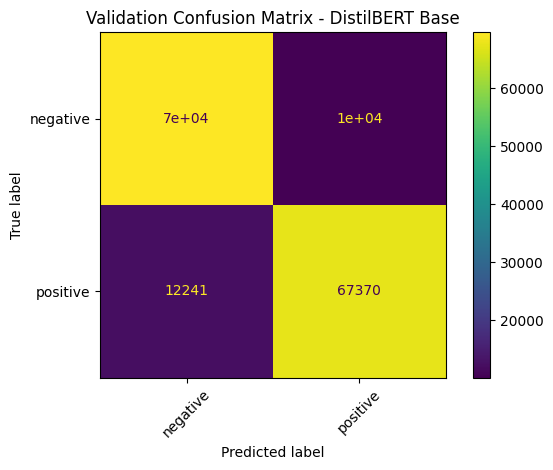

<Figure size 640x480 with 0 Axes>

In [ ]:
# Final eval on validation set
eval_results = trainer.evaluate()
print("Final eval metrics:", eval_results)

# Predictions
preds_output = trainer.predict(val_tok)
y_pred = preds_output.predictions.argmax(axis=1)
y_true = preds_output.label_ids

# ---- Per-class metrics table ----
# Adjust target_names and labels to reflect the actual classes (0 and 2) present in the data
target_names = ["negative", "positive"] # Removed 'neutral'
print("\nPer-class precision / recall / F1:\n")
print(classification_report(y_true, y_pred, labels=[0, 2], target_names=target_names))

# ---- Confusion matrix ----
# Adjusting labels to reflect the actual classes (0 and 2) present in the data
cm = confusion_matrix(y_true, y_pred, labels=[0, 2])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names,
)
disp.plot()
plt.title("Validation Confusion Matrix - DistilBERT Base")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Log final metrics + CM to W&B
wandb.log({
    "val/loss_final": eval_results["eval_loss"],
    "val/accuracy_final": eval_results["eval_accuracy"],
    "val/f1_macro_final": eval_results["eval_f1_macro"],
    "val/f1_weighted_final": eval_results["eval_f1_weighted"],
})

# Log confusion matrix as image
wandb.log({"confusion_matrix": wandb.Image(plt.gcf())})

# FINE TUNING

## Reload Base Model

In [ ]:
from transformers import AutoModelForSequenceClassification

# Load the best base model we saved earlier
print("Loading base model from:", BASE_MODEL_DIR)
ft_start_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL_DIR,
    num_labels=3,
    id2label=id2label,
    label2id={v: k for k, v in id2label.items()},
)

ft_start_model

Loading base model from: /content/drive/MyDrive/distilbert_sentiment140_base


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Set fine-tune output directories

In [ ]:
import os

FINE_TUNE_1 = "distilbert_sentiment140_ft1"  # you can change the suffix later
SAVE_DIR_FT_1 = f"/content/drive/MyDrive/{FINE_TUNE_1}"
OUTPUT_DIR_FT_1 = "./bert_output_ft1"

os.makedirs(SAVE_DIR_FT_1, exist_ok=True)

print("Fine-tuned model will be saved to:", SAVE_DIR_FT)
print("Trainer output dir:", OUTPUT_DIR_FT)

Fine-tuned model will be saved to: /content/drive/MyDrive/distilbert_sentiment140_ft1
Trainer output dir: ./bert_output_ft1


## Start a NEW W&B run (same project, new run)

In [ ]:
import wandb

wandb.finish()  # close the base run if it's still active

run_ft1 = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="distilbert-sentiment140-ft1",   # new run name
    config={
        "phase": "fine_tune_v1",
        "base_checkpoint": BASE_MODEL_DIR,
        "num_train_epochs": 2,            # extra epochs, base is 2, now it becomes 4
        "learning_rate": 1e-5,
        "batch_size": 32,
        "max_length": 128,
        "dataset_size": len(df),
    },
    reinit=True,
)

eval/accuracy,▁████
eval/f1_macro,▁████
eval/f1_weighted,▁████
eval/loss,█▁▁▁▁
eval/runtime,██▃▁▂
eval/samples_per_second,▁▁▆█▇
eval/steps_per_second,▁▁▆█▇
test/accuracy,▁▁▁
test/f1_macro,▁▁▁
test/f1_weighted,▁▁▁
+13,...


## Training Arguements for Fine Tuning

In [ ]:
from transformers import TrainingArguments

training_args_ft = TrainingArguments(
    output_dir=OUTPUT_DIR_FT,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2,          # +2 epochs on top of the base model Which already has 2 epochs
    learning_rate=1e-5,          # gentler LR for fine-tuning
    weight_decay=0.01,

    logging_strategy="steps",
    logging_steps=100,

    eval_strategy="epoch",       # eval each epoch (same as base run setup)
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    report_to=["wandb"],
    run_name="distilbert-sentiment140-ft1",
)

## Trainer + Fine Tune

In [ ]:
trainer_ft = Trainer(
    model=ft_start_model,
    args=training_args_ft,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

ft_train_result = trainer_ft.train()

# Save the best fine-tuned model + tokenizer
trainer_ft.save_model(SAVE_DIR_FT)
tokenizer.save_pretrained(SAVE_DIR_FT)

print("✅ Fine-tuned model saved to:", SAVE_DIR_FT)

/tmp/ipython-input-4142667124.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_ft = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.240000,0.389100,0.852211,0.852193,0.852194
2,0.272900,0.362213,0.853943,0.853913,0.853914


✅ Fine-tuned model saved to: /content/drive/MyDrive/distilbert_sentiment140_ft1


Fine-tuned eval metrics: {'eval_loss': 0.3622128665447235, 'eval_model_preparation_time': 0.0014, 'eval_accuracy': 0.8539431641985926, 'eval_f1_macro': 0.853913448230178, 'eval_f1_weighted': 0.8539144814878826, 'eval_runtime': 135.1746, 'eval_samples_per_second': 1178.483, 'eval_steps_per_second': 18.421}

Per-class precision / recall / F1 (fine-tuned):

              precision    recall  f1-score   support

    negative       0.84      0.87      0.86     79690
     neutral       0.00      0.00      0.00         0
    positive       0.86      0.84      0.85     79611

    accuracy                           0.85    159301
   macro avg       0.57      0.57      0.57    159301
weighted avg       0.85      0.85      0.85    159301



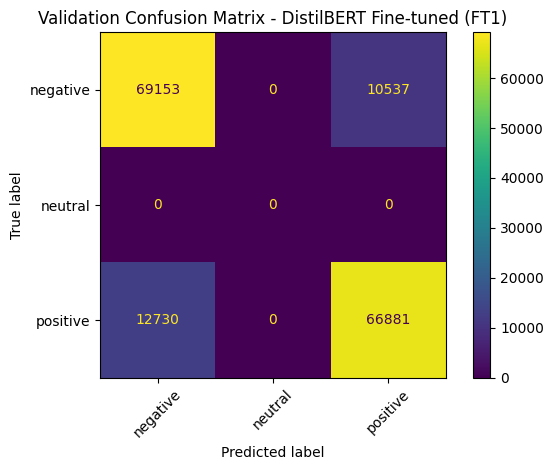

In [ ]:
# Overall metrics
eval_results_ft = trainer_ft_eval.evaluate()
print("Fine-tuned eval metrics:", eval_results_ft)

# Predictions
preds_output_ft = trainer_ft_eval.predict(val_tok)
y_pred_ft = preds_output_ft.predictions.argmax(axis=1)
y_true_ft = preds_output_ft.label_ids

labels = [0, 1, 2]
target_names = ["negative", "neutral", "positive"]

print("\nPer-class precision / recall / F1 (fine-tuned):\n")
print(
    classification_report(
        y_true_ft,
        y_pred_ft,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )
)

# Confusion matrix
cm_ft = confusion_matrix(y_true_ft, y_pred_ft, labels=labels)
disp_ft = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=target_names,
)
disp_ft.plot()
plt.title("Validation Confusion Matrix - DistilBERT Fine-tuned (FT1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()